<a href="https://colab.research.google.com/github/ashley-manzo/COSC-5360-AI-Projects/blob/main/AI_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded Successfully
Dataset shape (rows, columns): (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing Values by Column:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Dataset shape after dropping missing values: (113999, 21)

Class Counts:
is_hit
0    111168
1      2831
Name: count, dtype: int64

Class Propor

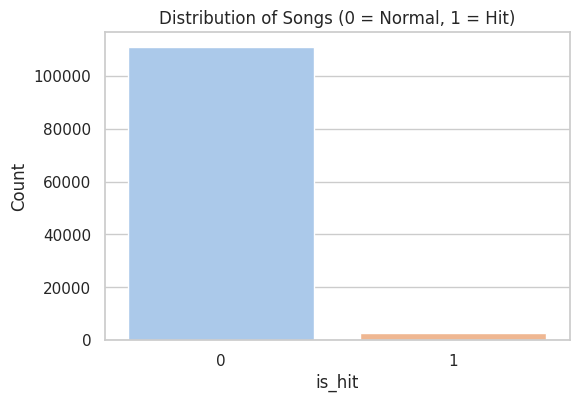

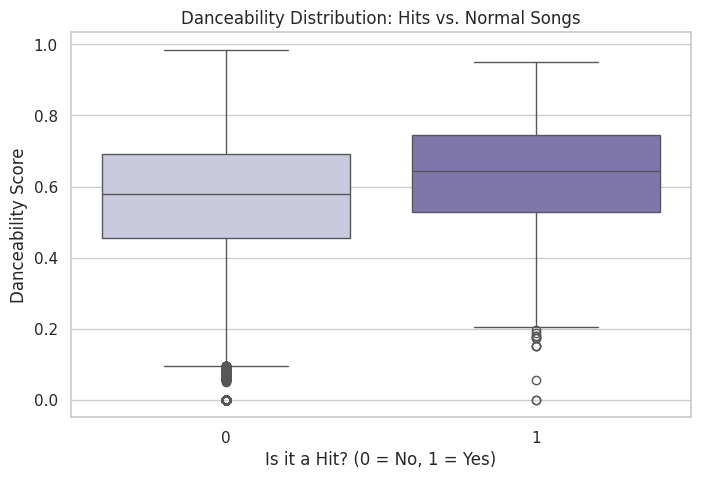


Train/Test Split Complete
X_train shape: (91199, 9)
X_test shape: (22800, 9)

Baseline Accuracy (predict all 0): 0.9752

Logistic Regression Results
Accuracy: 0.5946
ROC-AUC: 0.7263
              precision    recall  f1-score   support

           0      0.989     0.591     0.740     22234
           1      0.044     0.742     0.083       566

    accuracy                          0.595     22800
   macro avg      0.517     0.666     0.412     22800
weighted avg      0.966     0.595     0.723     22800


Starting Grid Search for Model Optimization...
Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validated F1 Score: 0.5702

Optimized Test Accuracy: 98.22%
Optimized Test ROC-AUC: 0.9061

Classification Report (Random Forest)
              precision    recall  f1-score   support

           0      0.992     0.990     0.991     22234
           1      0.631     0.686     0.657       566

  

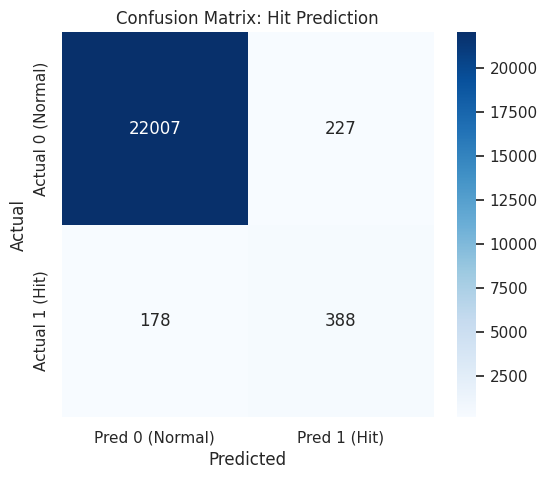

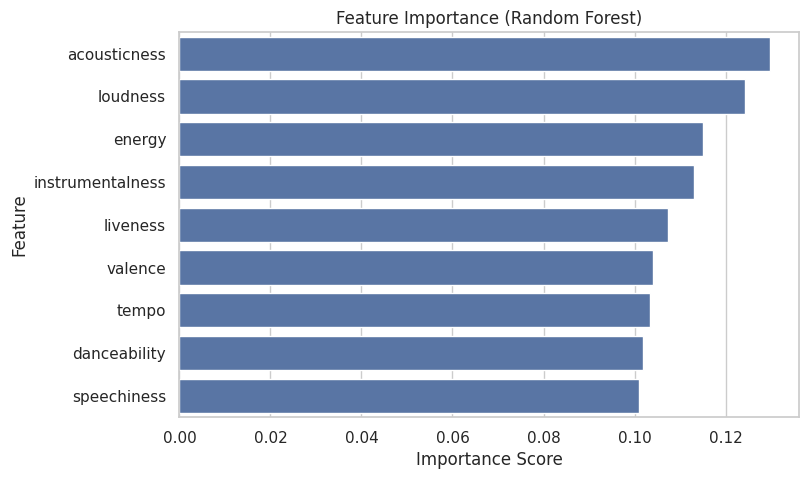

In [ ]:
# Midterm Project
# Ashley Manzo & Nylah Jackson
# What Makes A Song A Radio Hit?

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report. roc_auc_score

# 1. Load data
df = pd.read_csv('dataset.csv')

print("Data Loaded Successfully")
print(f"Dataset shape (rows, cols): {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Handle missing values
print("\nMissing Values by Column:")
print(df.isnull().sum())

df = df.dropna()
print(f"\nDataset shape after dropping missing values: {df.shape}")

# 3. Create target variable

# Hit song = 75 or higher (1), Normal = 74 and below (0)
df['is_hit'] = (df['popularity'] >= 75).astype(int)

# 4. Class distribution summary
class_counts = df['is_hit'].value_counts()
class_props = df['is_hit'].value_counts(normalize=True)

print("\nClass Counts:")
print(class_counts)

print("\nClass Proportions:")
print((class_props * 100).round(2).astype(str) + "%")

# 5. Styling to match PowerPoint
plt.style.use('dark_background')
pop_palette = ['#888888', '#00baf1']
title_pink = '#f272ab'
cyan_cmap = sns.dark_palette('#00baf1', as_cmap=True)

# 6. Visual 1: Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_hit', hue='is_hit', legend=False, palette=pop_palette)
plt.title('DISTRIBUTION OF SONGS (0 = NORMAL, 1 = HIT)', color=title_pink, fontweight='bold')
plt.xlabel('Is it a Hit? (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 7. Visual 2: Danceability
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_hit', y='danceability', hue='is_hit', legend=False, palette=pop_palette)
plt.title('DANCEABILITY DISTRIBUTION: HITS vs. NORMAL SONGS', color=title_pink, fontweight='bold')
plt.xlabel('Is it a Hit? (0 = No, 1 = Yes)')
plt.ylabel('Danceability Score')
plt.show()

# 8. Feature selection
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
y = df['is_hit']

# 9. Train/test split
# Stratify because the dataset is highly imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test Split Complete")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 10. Baseline accuracy
# Predict every song as normal (0)
baseline_pred = np.zeros_like(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"\nBaseline Accuracy (predict all 0): {baseline_acc:.4f}")

# 11. Algorithm 1: Logistic Regression
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, log_probs), 4))
print(classification_report(y_test, log_pred, digits=3))

# 12. Algorithm 2: Random Forest + Grid Search
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

print("Starting Grid Search for Model Optimization...")

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validated F1 Score: {grid_search.best_score_:.4f}")

# 13. Final Random Forest evaluation
predictions = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, predictions)
auc = roc_auc_score(y_test, probs)

print(f"\nOptimized Test Accuracy: {acc * 100:.2f}%")
print(f"Optimized Test ROC-AUC: {auc:.4f}")
print("\nClassification Report (Random Forest)")
print(classification_report(y_test, predictions, digits=3))

# 14. Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=cyan_cmap,
    xticklabels=['Pred 0 (Normal)', 'Pred 1 (Hit)'],
    yticklabels=['Actual 0 (Normal)', 'Actual 1 (Hit)']
)
plt.title('CONFUSION MATRIX: HIT PREDICTION ACCURACY', color=title_pink, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 15. Feature Importance Plot
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color='#00baf1')
plt.title('FEATURE IMPORTANCE (RANDOM FOREST)', color=title_pink, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()